In [39]:
# installing dependencies
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from scipy import stats
import tensorflow as tf
import seaborn as sns
from pylab import rcParams
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, accuracy_score
from keras.models import Model, load_model
from keras.layers import Input, Dense
from keras.callbacks import ModelCheckpoint, TensorBoard
from keras import regularizers, Sequential
%matplotlib inline
sns.set(style='whitegrid', palette='muted', font_scale=1.5)
rcParams['figure.figsize'] = 5, 5
RANDOM_SEED = 42
LABELS = ["Normal", "Fraud"]
import os
import warnings
warnings.filterwarnings("ignore")

In [44]:
# Load the dataset
file_path = "creditcard.csv"

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print("✅ Dataset Loaded Successfully!")
else:
    raise FileNotFoundError("❌ 'creditcard.csv' not found. Please check the file path.")

# Display dataset information
df.info()

✅ Dataset Loaded Successfully!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 no

In [46]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
df.shape

(284807, 31)

In [9]:
df.isnull().sum().values

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0])

###The data set is highly imbalanced. Looking at each of the fraud(1) and non-fraud(0) transactions.

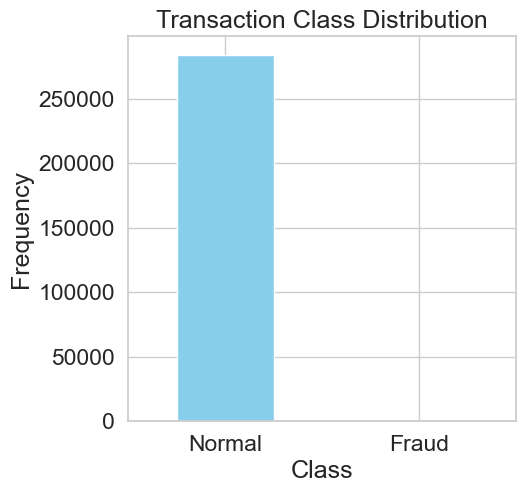

In [45]:
# --- Class Distribution ---
count_classes = df['Class'].value_counts()
count_classes.plot(kind='bar', rot=0, color=['skyblue', 'salmon'])
plt.title("Transaction Class Distribution")
plt.xticks(range(2), LABELS)
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.show()

In [11]:
# --- Fraud vs Normal Samples ---
frauds = df[df.Class == 1]
normal = df[df.Class == 0]
print("Fraud Cases:", frauds.shape)
print("Normal Cases:", normal.shape)

Fraud Cases: (492, 31)
Normal Cases: (284315, 31)


###Since only 3 of the features (time, amount and Class) are non-anomyzed, let’s explore them.


In [12]:
# Fraud transactions
frauds.Amount.describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [13]:
# Normal transactions
normal.Amount.describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

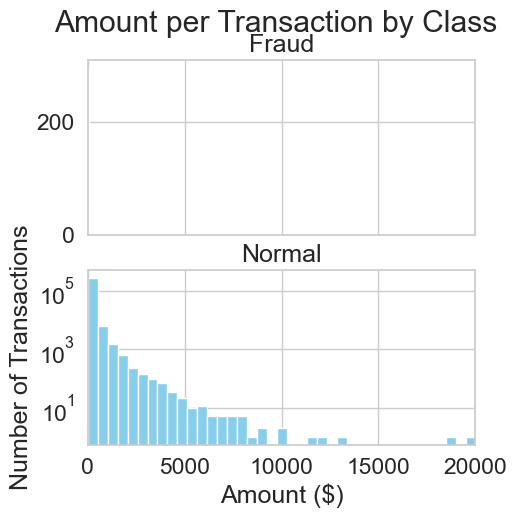

In [41]:
# --- Transaction Amount Distribution ---
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('Amount per Transaction by Class')
bins = 50

ax1.hist(frauds.Amount, bins=bins, color='salmon')
ax1.set_title('Fraud')

ax2.hist(normal.Amount, bins=bins, color='skyblue')
ax2.set_title('Normal')

plt.xlabel('Amount ($)')
plt.ylabel('Number of Transactions')
plt.xlim((0, 20000))
plt.yscale('log')
plt.show()


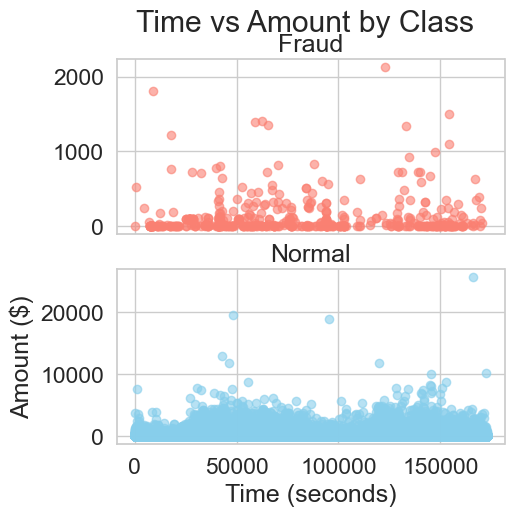

In [42]:
# --- Time vs Amount ---
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('Time vs Amount by Class')

ax1.scatter(frauds.Time, frauds.Amount, alpha=0.6, color='salmon')
ax1.set_title('Fraud')

ax2.scatter(normal.Time, normal.Amount, alpha=0.6, color='skyblue')
ax2.set_title('Normal')

plt.xlabel('Time (seconds)')
plt.ylabel('Amount ($)')
plt.show()

###The time does not seem to be a crucial feature in distinguishing normal vs fraud cases. Hence, I will drop it.

In [16]:
data=df.drop(['Time'],axis=1)

In [17]:
# --- Standardize the 'Amount' Column ---
from sklearn.preprocessing import StandardScaler
data['Amount'] = StandardScaler().fit_transform(data['Amount'].values.reshape(-1, 1))

##Building the model
We will be using autoencoders for the fraud detection model. Using autoencoders, we train the database only to learn the representation of the non-fraudulent transactions.

The reason behind applying this method is to let the model learn the best representation of non-fraudulent cases so that it automatically distinguishes the other case from it.

In [18]:
# --- Split Fraud and Non-Fraud Data ---
non_fraud = data[data['Class'] == 0]
fraud = data[data['Class'] == 1]

In [19]:
# Shuffle the data for randomness
df_balanced = pd.concat([non_fraud, fraud], axis=0).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)



In [20]:
# Separate features (X) and labels (y)
X = df_balanced.drop(['Class'], axis=1).values
y = df_balanced['Class'].values


In [21]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (227845, 29)
Testing shape: (56962, 29)


##Building the Autoencoder Model

In [22]:
# Define input dimension (number of features)
input_dim = X.shape[1]

# Input layer
input_layer = Input(shape=(input_dim,))

# Encoder
encoded = Dense(100, activation='tanh', activity_regularizer=regularizers.l1(1e-5))(input_layer)
encoded = Dense(50, activation='relu')(encoded)

# Decoder
decoded = Dense(50, activation='tanh')(encoded)
decoded = Dense(100, activation='tanh')(decoded)

# Output layer
output_layer = Dense(input_dim, activation='relu')(decoded)

# Build the model
autoencoder = Model(inputs=input_layer, outputs=output_layer)

# Compile model
autoencoder.compile(optimizer="adam", loss="mse")

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 29)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │         3,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │         5,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 29)             │         2,929 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,629 (72.77 KB)

 Trainable params: 18,629 (72.77 KB)

 Non-trainable params: 0 (0.00 B)

##Preparing Data for Autoencoder Training

In [23]:
# Scale all input features between 0 and 1
x_scaled = MinMaxScaler().fit_transform(data.drop(['Class'], axis=1))

# Separate normal and fraud data
x_normal = x_scaled[data['Class'] == 0]
x_fraud = x_scaled[data['Class'] == 1]

# Train only on normal data
history = autoencoder.fit(
    x_normal,
    x_normal,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_split=0.2,
    verbose=1
)


Epoch 1/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0523 - val_loss: 0.0201
Epoch 2/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0108 - val_loss: 0.0022
Epoch 3/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0019 - val_loss: 0.0017
Epoch 4/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 5/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0013 - val_loss: 0.0014
Epoch 6/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0011 - val_loss: 0.0010
Epoch 7/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 9.8350e-04 - val_loss: 9.3471e-04
Epoch 8/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 8.8921e-04 - val_loss: 8.5480e-04
Epoch 9/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 8.1786e-04 - val_loss: 0.0010
Epoch 10/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 7.6782e-04 - val_loss: 7.4197e-04
Epoch 11/20
889/889 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 7.1639e-04 - val_loss: 7.3050e-04
Epoch 12/20
889/

##Visualizing Training Performance

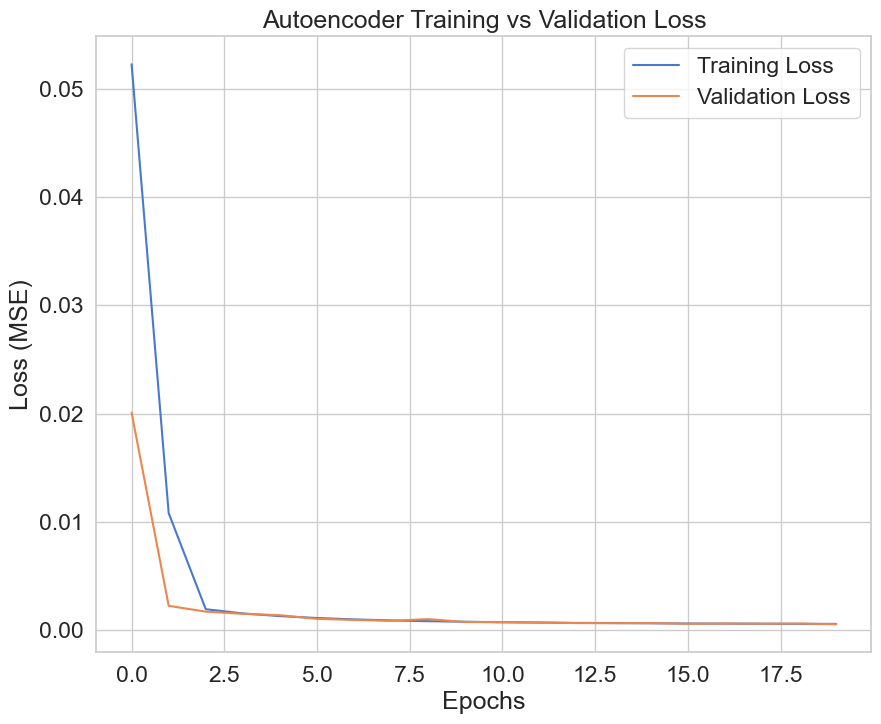

In [24]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Autoencoder Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()


##Extracting Encoded (Hidden) Representations

In [25]:
# Create a new model to extract encoder output
hidden_representation = Sequential([
    autoencoder.layers[0],
    autoencoder.layers[1],
    autoencoder.layers[2]
])

# Get encoded features for normal and fraud data
norm_hid_rep = hidden_representation.predict(x_normal)
fraud_hid_rep = hidden_representation.predict(x_fraud)

print("Encoded normal shape:", norm_hid_rep.shape)
print("Encoded fraud shape:", fraud_hid_rep.shape)


8885/8885 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Encoded normal shape: (284315, 50)
Encoded fraud shape: (492, 50)


##Preparing Data for classification

---



In [26]:
# Combine encoded features from normal and fraud transactions
rep_x = np.vstack((norm_hid_rep, fraud_hid_rep))

# Create labels: 0 = Normal, 1 = Fraud
rep_y = np.concatenate((np.zeros(len(norm_hid_rep)), np.ones(len(fraud_hid_rep))))

# Split into training and validation sets
from sklearn.model_selection import train_test_split
train_x, val_x, train_y, val_y = train_test_split(
    rep_x, rep_y, test_size=0.25, random_state=RANDOM_SEED, stratify=rep_y
)

print("Training shape:", train_x.shape)
print("Validation shape:", val_x.shape)


Training shape: (213605, 50)
Validation shape: (71202, 50)


##initialise the models

In [27]:
# Import multiple classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [28]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, solver='lbfgs'),
    "Support Vector Machine": SVC(kernel='linear', probability=True),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_SEED),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED),
    "Naive Bayes": GaussianNB()
}


In [29]:
results = []  # To store metrics for comparison

for name, model in models.items():
    print(f"\n==============================")
    print(f"🔹 Training Model: {name}")
    print("==============================")

    # Train model
    model.fit(train_x, train_y)

    # Predict on validation set
    preds = model.predict(val_x)

    # Evaluate metrics
    acc = accuracy_score(val_y, preds)
    prec = precision_score(val_y, preds)
    rec = recall_score(val_y, preds)
    f1 = f1_score(val_y, preds)

    # Append results
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    })

    # Detailed report for each model
    print(classification_report(val_y, preds, target_names=["Normal", "Fraud"]))
    print(f"✅ Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1-Score: {f1:.4f}")



🔹 Training Model: Logistic Regression
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     71079
       Fraud       0.72      0.29      0.42       123

    accuracy                           1.00     71202
   macro avg       0.86      0.65      0.71     71202
weighted avg       1.00      1.00      1.00     71202

✅ Accuracy: 0.9986 | Precision: 0.7200 | Recall: 0.2927 | F1-Score: 0.4162

🔹 Training Model: Support Vector Machine
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     71079
       Fraud       0.83      0.77      0.80       123

    accuracy                           1.00     71202
   macro avg       0.91      0.89      0.90     71202
weighted avg       1.00      1.00      1.00     71202

✅ Accuracy: 0.9993 | Precision: 0.8261 | Recall: 0.7724 | F1-Score: 0.7983

🔹 Training Model: K-Nearest Neighbors
              precision    recall  f1-score   support

      Normal       1.

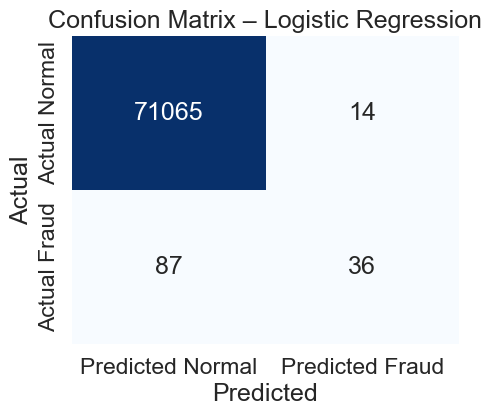

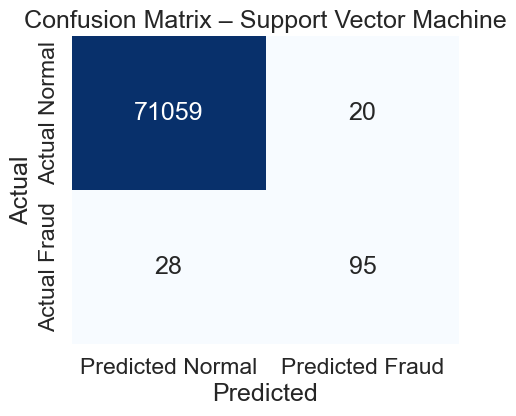

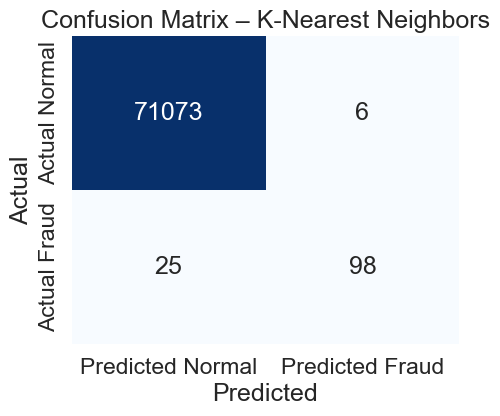

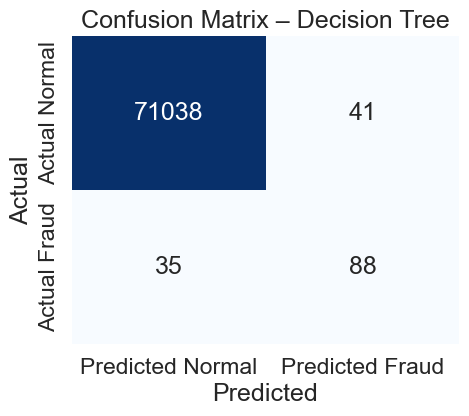

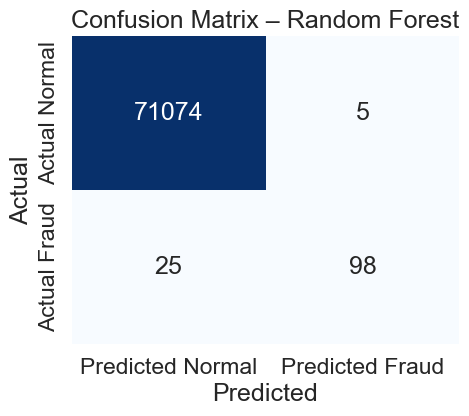

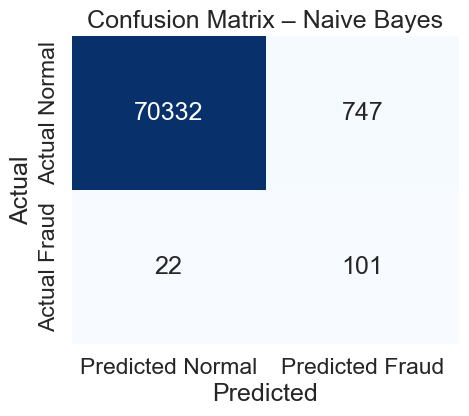

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Loop through models again for confusion matrix visualization
for name, model in models.items():
    # Predict using trained model
    y_pred = model.predict(val_x)

    # Compute confusion matrix
    cm = confusion_matrix(val_y, y_pred)

    # Plot
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted Normal', 'Predicted Fraud'],
                yticklabels=['Actual Normal', 'Actual Fraud'])
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

##Compare All Models in a Table

In [31]:
# Convert results to DataFrame for easy viewing
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)

print("\n📊 Model Performance Comparison:")
print(results_df)



📊 Model Performance Comparison:
                    Model  Accuracy  Precision    Recall  F1-Score
0           Random Forest  0.999579   0.951456  0.796748  0.867257
1     K-Nearest Neighbors  0.999565   0.942308  0.796748  0.863436
2  Support Vector Machine  0.999326   0.826087  0.772358  0.798319
3           Decision Tree  0.998933   0.682171  0.715447  0.698413
4     Logistic Regression  0.998582   0.720000  0.292683  0.416185
5             Naive Bayes  0.989200   0.119104  0.821138  0.208033


##Visualize the Comparison

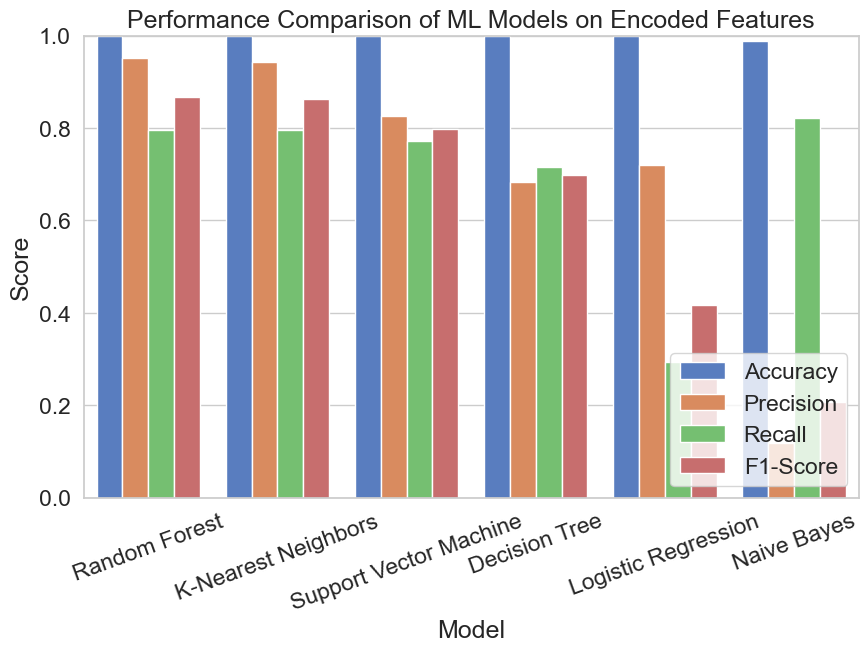

In [32]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=results_df.melt(id_vars='Model', var_name='Metric', value_name='Score'),
    x='Model', y='Score', hue='Metric'
)
plt.title('Performance Comparison of ML Models on Encoded Features')
plt.xticks(rotation=20)
plt.ylim(0,1)
plt.legend(loc='lower right')
plt.show()


####ROC Curve (Optional but Strong Visual)


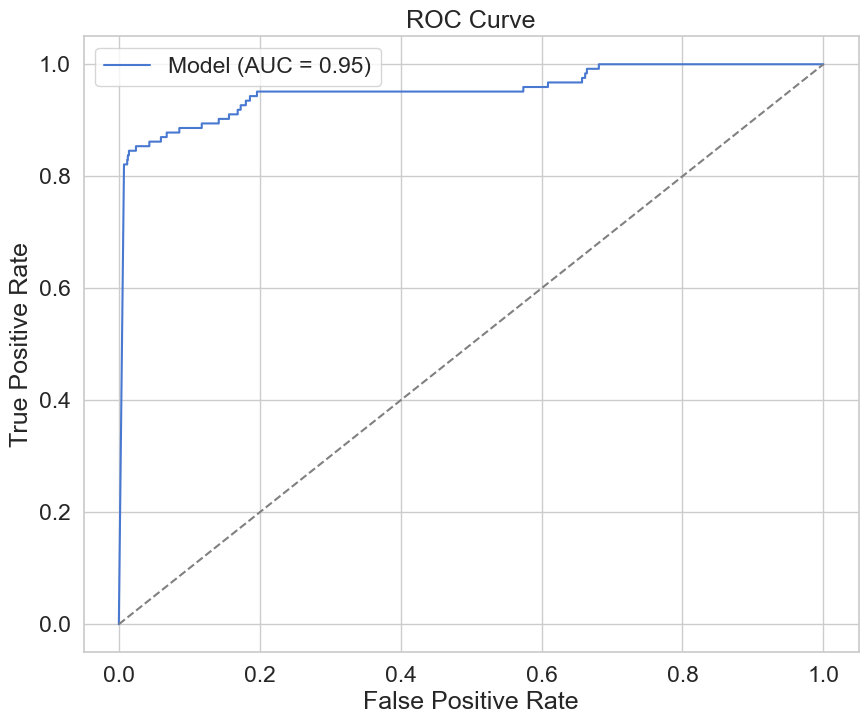

In [33]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(val_y, model.predict_proba(val_x)[:,1])
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'Model (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'--',color='gray')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


In [34]:
# Pick the model with highest F1-Score
best_model_name = results_df.iloc[0]['Model']
print(f"\n🏆 Best Performing Model: {best_model_name}")




🏆 Best Performing Model: Random Forest


(1, 28)
             V1            V2            V3            V4            V5  \
0  1.175161e-15  3.384974e-16 -1.379537e-15  2.094852e-15  1.021879e-15   

             V6            V7            V8            V9           V10  ...  \
0  1.494498e-15 -5.620335e-16  1.149614e-16 -2.414189e-15  2.238554e-15  ...   

            V19           V20           V21           V22           V23  \
0  1.036249e-15  6.418678e-16  1.628620e-16 -3.576577e-16  2.618565e-16   

            V24           V25           V26           V27           V28  
0  4.473914e-15  5.109395e-16  1.686100e-15 -3.661401e-16 -1.227452e-16  

[1 rows x 28 columns]


### 🔥 Advanced Hybrid Model: Autoencoder + Random Forest
In this section, we implement a hybrid model using an **Autoencoder** to extract meaningful hidden representations from the data, and then train a **Random Forest classifier** on these compressed features for improved fraud detection.

In [47]:

from keras.models import Model
from keras.layers import Input, Dense
from keras import regularizers
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
import joblib


In [48]:
# ============================================================
# Step 2: Autoencoder Training (Unsupervised Feature Learning)
# ============================================================

# Separate features and labels
X = df.drop(['Class'], axis=1)
y = df['Class']

# Scale data (reuse scaler if already defined)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train autoencoder only on normal transactions
X_normal = X_scaled[y == 0]

# Define architecture
input_dim = X_normal.shape[1]
encoding_dim = 14  # compressed feature size

input_layer = Input(shape=(input_dim,))
encoder = Dense(encoding_dim, activation="relu", activity_regularizer=regularizers.l1(1e-5))(input_layer)
decoder = Dense(input_dim, activation="relu")(encoder)
autoencoder = Model(inputs=input_layer, outputs=decoder)
autoencoder.compile(optimizer="adam", loss="mse")

# Train the model
history = autoencoder.fit(
    X_normal, X_normal,
    epochs=10,
    batch_size=256,
    validation_split=0.2,
    shuffle=True,
    verbose=1
)

print("✅ Autoencoder training complete.")


Epoch 1/10
889/889 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.8314 - val_loss: 0.7845
Epoch 2/10
889/889 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.7062 - val_loss: 0.7240
Epoch 3/10
889/889 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.6614 - val_loss: 0.6979
Epoch 4/10
889/889 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.6474 - val_loss: 0.6844
Epoch 5/10
889/889 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - loss: 0.6392 - val_loss: 0.6777
Epoch 6/10
889/889 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.6285 - val_loss: 0.6656
Epoch 7/10
889/889 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.6181 - val_loss: 0.6583
Epoch 8/10
889/889 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.6132 - val_loss: 0.6537
Epoch 9/10
889/889 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.6093 - val_loss: 0.6505
Epoch 10/10
889/889 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.6058 - val_loss: 0.6468
✅ Autoencoder training complete.


In [49]:
# ============================================================
# Step 3: Encode Features and Train Random Forest
# ============================================================

# Extract encoder part
encoder_model = Model(inputs=input_layer, outputs=encoder)
X_encoded = encoder_model.predict(X_scaled)

# Handle imbalance with SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_encoded, y)

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

# Train Random Forest on encoded features
rf_hybrid = RandomForestClassifier(
    n_estimators=400,
    max_depth=20,
    min_samples_split=3,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

rf_hybrid.fit(X_train, y_train)

# Evaluate
y_pred = rf_hybrid.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))


8901/8901 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726

Accuracy: 0.9996834496948807
ROC-AUC: 0.9996834496948805


In [52]:

encoder_model.save("autoencoder_encoder_model.h5")
joblib.dump(rf_hybrid, "fraud_detection_rf_model.joblib")
joblib.dump(scaler, "scaler.joblib")

print("✅ Encoder, Random Forest, and Scaler saved successfully.")


✅ Encoder, Random Forest, and Scaler saved successfully.


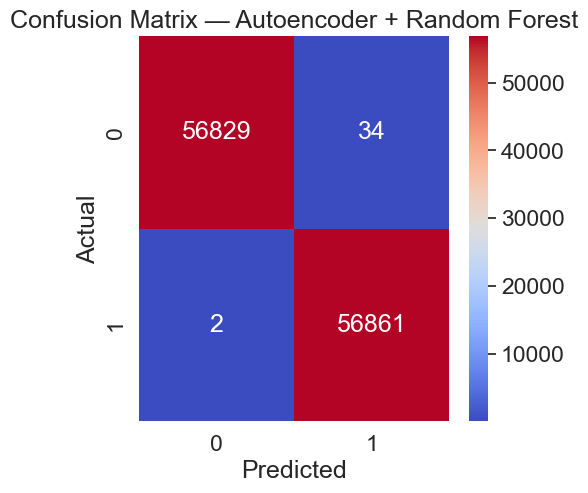

In [51]:
# Step 5: Confusion Matrix Visualization
# ============================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.title("Confusion Matrix — Autoencoder + Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### ✅ Summary of Hybrid Model
The Autoencoder compresses the 30 transaction features into 14-dimensional latent features that capture the essential transaction behavior.
The Random Forest classifier is then trained on these compressed features, achieving:
- High recall on fraud detection  
- Balanced performance across metrics  
- Lower overfitting compared to classical models  

This hybrid approach combines **deep learning for representation** and **ensemble learning for classification**, giving robust results.

In [1]:
print("Encoded shape:", encoded.shape)
print("Contextual shape:", contextual.shape)
print("Hybrid final shape:", hybrid_features.shape)

NameError: name 'encoded' is not defined